# AAA_t_test6: simple multi-frequency real-axis test

This notebook follows the scalar-filtering format of `AAA_t_test5`, but repeats the calculation for several Matsubara frequencies. It fits `AAA_tube` for `G_00` and `G_01`, evaluates the rational approximations only on the real axis `Im(t)=0`, stores the results in arrays, and plots all selected frequencies together.


In [28]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

from t_complex_interpolation_workflow import (
    compute_exact_t,
    compute_sce_t,
    compute_wce_t,
    build_t_app_G_app_scalar,
)
from _bary_rational import AAA_tube, AAA_tube_v2


In [29]:
# Hubbard dimer and Matsubara setup.
beta = 5.0
Ns = 2
Nw = 4 * int(beta)
Mat_fre = (2 * np.linspace(0, Nw - 1, Nw) + 1) * np.pi / beta
wn = np.append(-np.flip(Mat_fre), Mat_fre)

U = 8.0
T = 20.0
sce_order = 12
wce_order = 12
epsilon = 1e-6

# Select the Matsubara frequencies to test.
wn_id = [Nw - 1, Nw-5, Nw-10, Nw-15]
wn_selected = wn[wn_id]
print("selected Matsubara indices:", wn_id)
print("selected omegas:", wn_selected)


selected Matsubara indices: [19, 15, 10, 5]
selected omegas: [ -0.62831853  -5.65486678 -11.93805208 -18.22123739]


In [30]:
# Source tube for building filtered SCE/WCE training data.
source_tube_real_window = (-T, T)
source_tube_delta = 1.0
source_N_real = 501
source_N_imag = 101

# AAA_tube pole/boundary constraint settings.
aaa_tube_real_window = (-T, T)
aaa_tube_delta = 0.5
aaa_tube_Ns = 100000
max_terms = 50
max_error = epsilon

# Real-axis evaluation grid.
Nt_line = 2001
t_real = np.linspace(-T, T, Nt_line)


In [31]:
def make_tube_lattice(real_window, delta, n_real, n_imag):
    lo, hi = real_window
    real_axis = np.linspace(lo, hi, n_real)
    imag_axis = np.linspace(-delta, delta, n_imag)
    real_grid, imag_grid = np.meshgrid(real_axis, imag_axis)
    return real_grid + 1j * imag_grid


In [32]:
# Compute exact/SCE/WCE on the source tube for all selected frequencies.
source_t_grid = make_tube_lattice(
    source_tube_real_window,
    source_tube_delta,
    source_N_real,
    source_N_imag,
)
source_t_values = source_t_grid.ravel()

G_exact_source = compute_exact_t(source_t_values, wn_selected, U, beta)
G_sce_source = compute_sce_t(sce_order, source_t_values, wn_selected, U, beta)
G_wce_source = compute_wce_t(wce_order, source_t_values, wn_selected, U)

print("source grid shape:", source_t_grid.shape)
print("source point count:", source_t_values.size)
print("G_exact_source shape:", G_exact_source.shape)
print("finite exact entries:", np.isfinite(G_exact_source).sum(), "of", G_exact_source.size)


source grid shape: (101, 501)
source point count: 50601
G_exact_source shape: (50601, 4, 2, 2)
finite exact entries: 809616 of 809616


In [33]:
# Fit AAA_tube for each selected frequency and evaluate the rational functions on Im(t)=0.
G_exact_real = compute_exact_t(t_real, wn_selected, U, beta)
G00_aaa_real = np.zeros((Nt_line, len(wn_id)), dtype=complex)
G01_aaa_real = np.zeros((Nt_line, len(wn_id)), dtype=complex)

r00_by_n = {}
r01_by_n = {}
fit_summary = []

for col, n in enumerate(wn_id):
    omega = wn[n]
    print("\nfrequency index:", n, "omega:", omega)

    t_app_00, G_app_00 = build_t_app_G_app_scalar(
        G_sce_source[:, col, 0, 0],
        G_wce_source[:, col, 0, 0],
        G_exact_source[:, col, 0, 0],
        source_t_values,
        epsilon,
    )
    t_app_01, G_app_01 = build_t_app_G_app_scalar(
        G_sce_source[:, col, 0, 1],
        G_wce_source[:, col, 0, 1],
        G_exact_source[:, col, 0, 1],
        source_t_values,
        epsilon,
    )

    if t_app_00.size < 2:
        raise ValueError(f"Not enough filtered G_00 points for n={n}: {t_app_00.size}")
    if t_app_01.size < 2:
        raise ValueError(f"Not enough filtered G_01 points for n={n}: {t_app_01.size}")

    r00 = AAA_tube(
        t_app_00,
        G_app_00,
        rtol=max_error,
        max_terms=max_terms,
        delta=aaa_tube_delta,
        Ns=aaa_tube_Ns,
        tube_real_window=aaa_tube_real_window,
    )
    r01 = AAA_tube(
        t_app_01,
        G_app_01,
        rtol=max_error,
        max_terms=max_terms,
        delta=aaa_tube_delta,
        Ns=aaa_tube_Ns,
        tube_real_window=aaa_tube_real_window,
    )

    r00_by_n[n] = r00
    r01_by_n[n] = r01
    G00_aaa_real[:, col] = r00(t_real)
    G01_aaa_real[:, col] = r01(t_real)
    fit_summary.append((n, omega, t_app_00.size, t_app_01.size, r00._tube_max_error, r01._tube_max_error))

print("\nfit summary: (n, omega, N_G00, N_G01, G00 max_error, G01 max_error)")
for row in fit_summary:
    print(row)



frequency index: 19 omega: -0.6283185307179586
Selected scalar complex t points: 37999 of 50601 | SCE valid: 553 | WCE valid: 37446
Selected scalar complex t points: 37563 of 50601 | SCE valid: 181 | WCE valid: 37382
AAA_tube using best tube-safe iterate before max_terms.
AAA_tube warning constraints satisfied:
  max_error <= target: False
  poles outside tube: True
  boundary max < 1: True
AAA_tube warning final max_error: 5.558468646567143e-06
AAA_tube warning target max_error: 1e-06
AAA_tube final poles: [-0.36928229+2.58906317j  0.47790997+2.36577804j -0.25510303-2.67135753j
  0.45628652-2.15766881j -0.75228272+0.87558955j  0.83525912+0.74733373j
  0.82859477-0.70120803j -0.64978582-0.78184144j -0.33721599-0.94762379j]
AAA_tube tube real interval: (-20.0, 20.0)
AAA_tube tube delta: 0.5
AAA_tube poles inside tube: []
AAA_tube maximum boundary |r(z)|: 0.04617648142899974
AAA_tube final max_error: 5.558468646567143e-06
AAA_tube target max_error: 1e-06


/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/t_interpolation/../_bary_rational.py:67: RuntimeWarning: AAA_tube failed to satisfy all constraints within 50 iterations.
  self._compute_weights(z, f, **kwargs)


AAA_tube final poles: [-2.40010121e+00-1.22170735j -2.40686744e+00+1.15097779j
 -5.00596975e-03-2.52303895j  2.38020303e+00-1.12458982j
  2.35041469e+00+1.15252726j -3.56313239e-04+2.52500542j
 -1.39480621e+00-0.64148894j -9.13620329e-01-1.20698356j
 -3.12165615e-02-1.25870055j  8.92772035e-01-1.21972941j
  1.38219926e+00-0.66081187j -1.38110018e+00+0.65870246j
 -8.99701082e-01+1.21925996j  1.39369031e+00+0.65915646j
  9.06101754e-01+1.22229662j  6.01623901e-03+1.27714987j]
AAA_tube tube real interval: (-20.0, 20.0)
AAA_tube tube delta: 0.5
AAA_tube poles inside tube: []
AAA_tube maximum boundary |r(z)|: 0.6495684417364851
AAA_tube final max_error: 3.950604755400102e-11
AAA_tube target max_error: 1e-06

frequency index: 15 omega: -5.654866776461628
Selected scalar complex t points: 40431 of 50601 | SCE valid: 831 | WCE valid: 39600
Selected scalar complex t points: 39763 of 50601 | SCE valid: 295 | WCE valid: 39468
AAA_tube using best tube-safe iterate before max_terms.
AAA_tube warnin

In [34]:
# Save the real-axis approximation arrays in memory for later notebook cells.
results = {
    "t_real": t_real,
    "wn_id": np.array(wn_id),
    "wn_selected": wn_selected,
    "G_exact_real": G_exact_real,
    "G00_aaa_real": G00_aaa_real,
    "G01_aaa_real": G01_aaa_real,
    "fit_summary": fit_summary,
}
print("saved result keys:", list(results.keys()))


saved result keys: ['t_real', 'wn_id', 'wn_selected', 'G_exact_real', 'G00_aaa_real', 'G01_aaa_real', 'fit_summary']


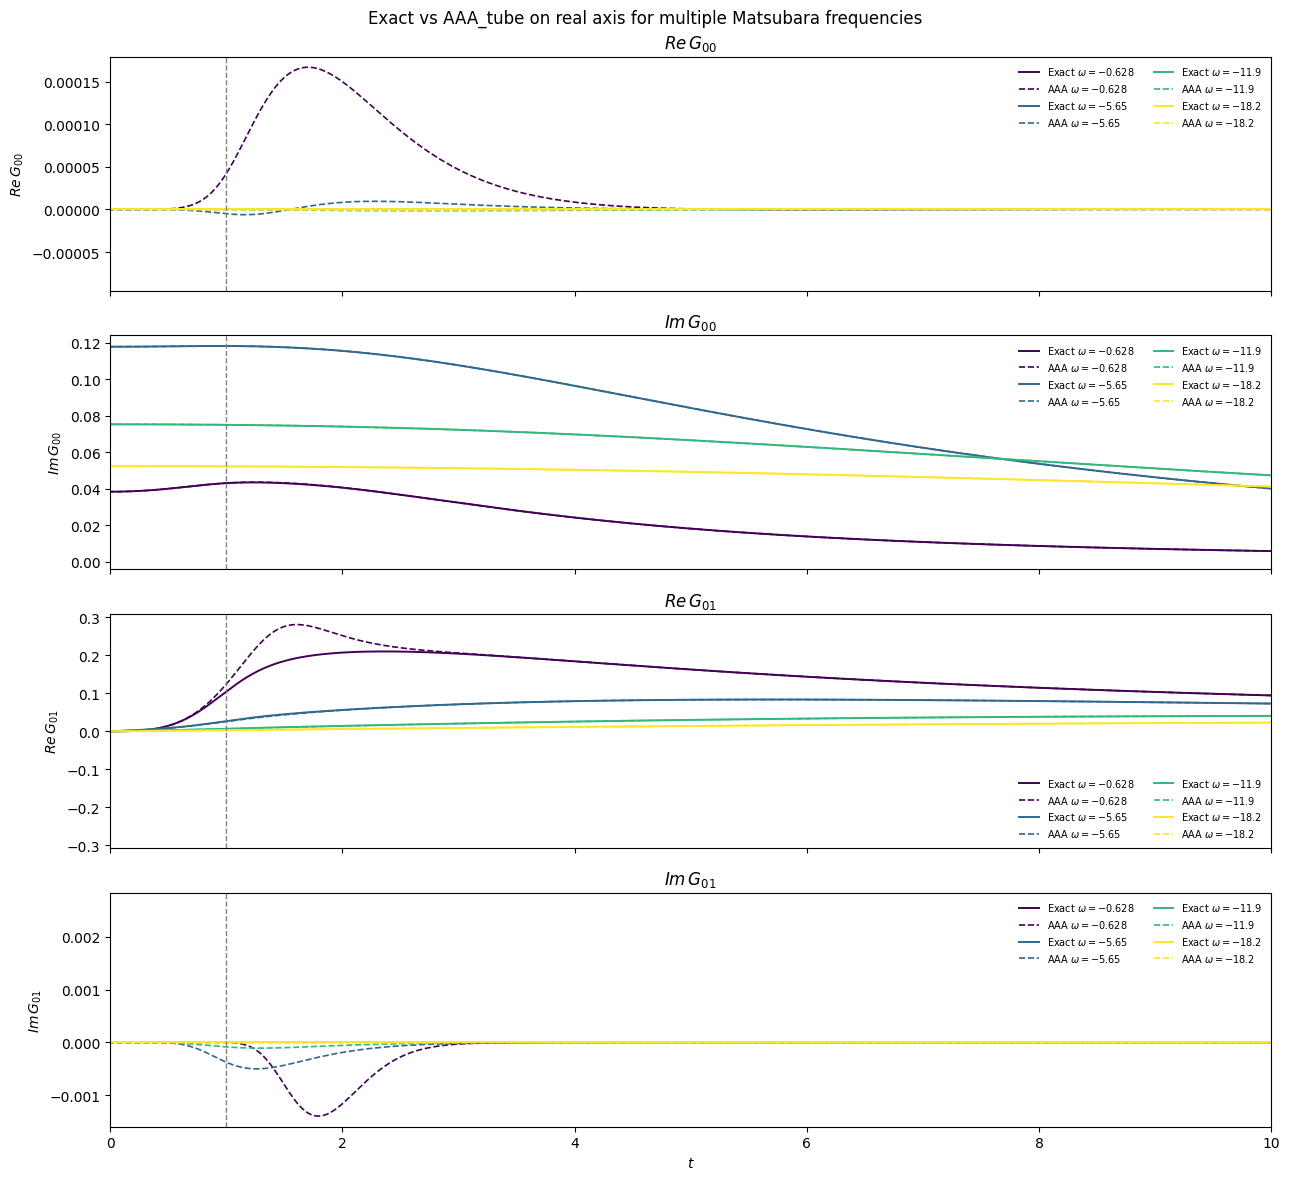

In [35]:
# Plot exact vs AAA_tube on Im(t)=0 for all selected frequencies.
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
components = [
    (G_exact_real[:, :, 0, 0].real, G00_aaa_real.real, r"$Re\,G_{00}$"),
    (G_exact_real[:, :, 0, 0].imag, G00_aaa_real.imag, r"$Im\,G_{00}$"),
    (G_exact_real[:, :, 0, 1].real, G01_aaa_real.real, r"$Re\,G_{01}$"),
    (G_exact_real[:, :, 0, 1].imag, G01_aaa_real.imag, r"$Im\,G_{01}$"),
]

colors = plt.cm.viridis(np.linspace(0, 1, len(wn_id)))
for row, (exact_values, aaa_values, title) in enumerate(components):
    ax = axes[row]
    for col, n in enumerate(wn_id):
        ax.plot(t_real, exact_values[:, col], color=colors[col], linewidth=1.4, label=rf"Exact $\omega={wn[n]:.3g}$")
        ax.plot(t_real, aaa_values[:, col], color=colors[col], linestyle="--", linewidth=1.2, label=rf"AAA $\omega={wn[n]:.3g}$")
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(0, 10)
    # ax.set_ylim(-0.5, 0.5)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=7, ncol=2)

axes[-1].set_xlabel(r"$t$")
fig.suptitle(r"Exact vs AAA_tube on real axis for multiple Matsubara frequencies")
fig.tight_layout()
plt.show()


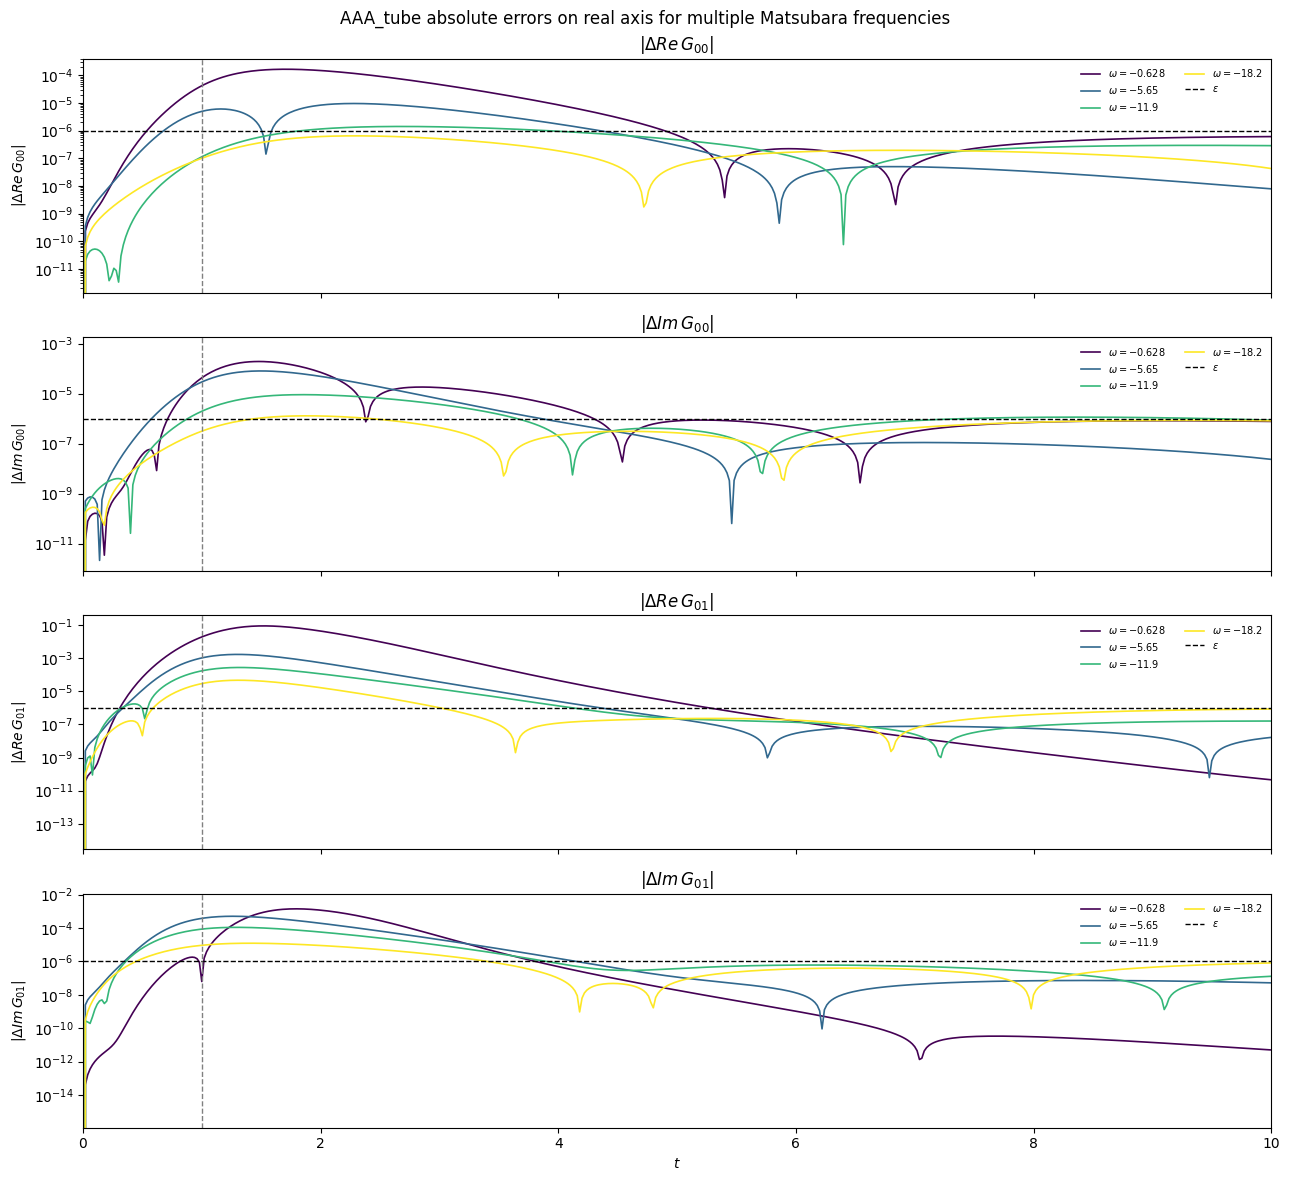

In [36]:
# Optional: real-axis absolute errors for all selected frequencies.
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
error_components = [
    (np.abs(G00_aaa_real.real - G_exact_real[:, :, 0, 0].real), r"$|\Delta Re\,G_{00}|$"),
    (np.abs(G00_aaa_real.imag - G_exact_real[:, :, 0, 0].imag), r"$|\Delta Im\,G_{00}|$"),
    (np.abs(G01_aaa_real.real - G_exact_real[:, :, 0, 1].real), r"$|\Delta Re\,G_{01}|$"),
    (np.abs(G01_aaa_real.imag - G_exact_real[:, :, 0, 1].imag), r"$|\Delta Im\,G_{01}|$"),
]

for row, (err_values, title) in enumerate(error_components):
    ax = axes[row]
    for col, n in enumerate(wn_id):
        ax.semilogy(t_real, err_values[:, col], color=colors[col], linewidth=1.2, label=rf"$\omega={wn[n]:.3g}$")
    ax.axhline(epsilon, color="k", linestyle="--", linewidth=1, label=r"$\epsilon$")
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(0, 10)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=7, ncol=2)

axes[-1].set_xlabel(r"$t$")
fig.suptitle(r"AAA_tube absolute errors on real axis for multiple Matsubara frequencies")
fig.tight_layout()
plt.show()
